## **The Changing Cost of Homeownership in the U.S**

## **1. Team:**
Team: Stat Squad

Team Members: Emily Aguilar (emilyo2), Yasmine Chatila (ychati2), Zahabiya Lokhandwala (zlokh2), Tasneem Mubashshira (tmubas2), Angel Corral-Esparza (acorr24)

Data Sources:
Zillow Home Values Dataset(URL: https://www.zillow.com/research/data/), 
FRED Median Household Income Dataset(URL: https://fred.stlouisfed.org/release/tables?rid=249&eid=259515&od=#)

Github: https://github.com/uic-cs418/group=project-stat-squad.git

## **2. Project introduction:**
This project analyzes the growing gap between median income and home prices across U.S. states from 2000 to 2023. Using yearly income data and aggregated home value data, we compared trends to understand why homeownership is becoming less affordable—even as incomes rise. Our hypothesis is that housing prices are outpacing income growth, especially in certain regions.

To explore this, we created visualizations and used unsupervised machine learning to cluster states by affordability. The results reveal clear regional patterns and highlight where homeownership remains attainable—and where it’s slipping away.

## **3. Data cleaning:**
**Zillow Home Values Dataset:** The zillow dataset contains monthly median home values from January 2000 to 2025 for 895 U.S. regions, with each row representing a region and each column (from the 6th onward) representing a specific month. The dataset has a high temporal granularity (monthly) and a wide spatial scope, covering diverse regions across the U.S. The timestamps were originally in string format and were converted to datetime objects for accurate time-based analysis. We found significant missing data. We removed the rows with more than 40% missing data. For the remaining missing values, we applied linear interpolation across time (columns), followed by forward and backward fill to handle edge cases. All numeric values were explicitly converted to float to ensure consistency and compatibility with analysis tools.

**Median Income Dataset:** The income dataset contains annual median household income for each U.S. state from 2000 to 2023. The income values included commas (e.g., "$75,000"), which were removed, and all values were converted to numeric types. To enable merging with the home values dataset, a new column for state codes (e.g., "IL" for Illinois) was added using a standard name-to-code mapping. Both datasets were aligned on state codes for consistency in comparative analysis. No missing values were found in the income data, so no imputation was necessary.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
pio.renderers.default = 'png'
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import numpy as np
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')
import all_functions

In [2]:
home_values_dataset = pd.read_csv('homevalue.csv')
income = pd.read_csv('median_income.csv')
home_values_dataset.columns.values[5:] = pd.to_datetime(home_values_dataset.columns[5:])

In [3]:
#Cleaning Data
threshold = 0.4
home_values = home_values_dataset.loc[home_values_dataset.isnull().mean(axis=1) < threshold]

In [4]:
# Interpolate across columns (i.e., across time for each region)
home_values.iloc[:, 5:] = home_values.iloc[:, 5:].interpolate(axis=1)
# Fill any remaining edge NaNs with forward/backward fill
home_values.iloc[:, 5:] = home_values.iloc[:, 5:].bfill(axis=1).ffill(axis=1)

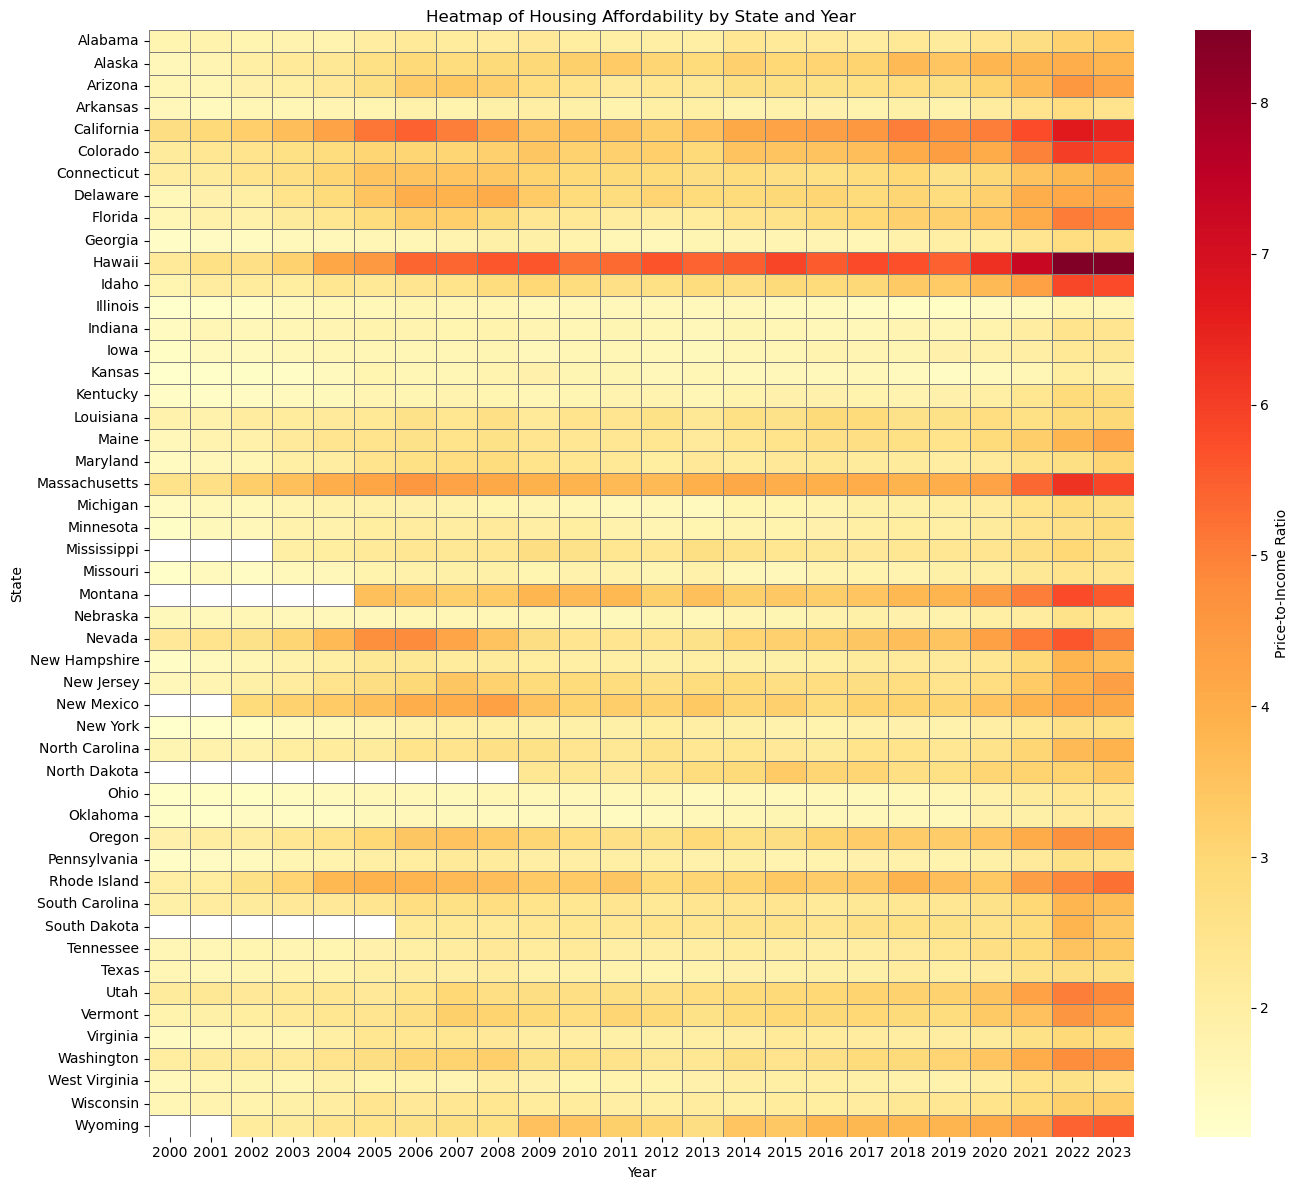

In [12]:

"""This functions adds state abbreviations and cleans the datasets by changing the format to long. It then merges the home_value and income datasets 
and calulates the price to income ratio by dividing the median house price by the median inome in each state for each year. 
Then presents the data in a heatmap showcasing affordability in each state."""
merged = all_functions.showHeatMap(home_values_dataset,income)

## **5. Visualizations**

### Hypothesis:  Median household income in the United States has not increased at the same rate as median home values, making it increasingly difficult for people to afford buying a home###

### **Visualization 1 : Diverging Trends: U.S. National Median Income vs. Home Value (2000–2023)**
This line chart compares the national median income and national median home value in the United States from 2000 to 2023. While median income has increased only modestly over the two decades, home values have risen sharply—especially after 2020. This divergence indicates a growing affordability gap, where home prices are increasing faster than people's ability to pay for them. This trend helps explain why first-time homeownership has become increasingly out of reach for many Americans.

In [13]:
national_trends = merged.groupby('Year').agg({
    'MedianIncome': 'mean',
    'HomeValue': 'mean'
}).reset_index()

plt.figure(figsize=(8, 4))
plt.plot(national_trends['Year'], national_trends['MedianIncome'], label='National Median Income', marker='o')
plt.plot(national_trends['Year'], national_trends['HomeValue'], label='National Median Home Value', marker='s')
plt.title("U.S. National Median Income vs Home Value (2000–2023)")
plt.xlabel("Year")
plt.ylabel("USD")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

AttributeError: 'NoneType' object has no attribute 'groupby'

### **Visualization 2 : Ideal Home Values vs Real Home Values**
ADD DESC

In [8]:
"code"
plt.show()

### **Visualization 3 : Ideal Month to buy a home**
ADD DESC

In [8]:
"code"
plt.show()

## **6. Machine Learning analysis**
The goal of this ML analysis is to identify patterns in affordability accross US states that are not immediately visible in raw data, and to segment states into categories with respect to their affordability.

In [8]:
state_yearly_df = all_functions.homevalues_dataset(home_values)

In [9]:
income = pd.read_csv('median_income.csv')
income = all_functions.income_dataset_ML(income)

homevalues_dataset() and income_dataset_ML() function prepares the homevalues and income data to feed into the clustering algorithm. Homevalues of all the regions of each state are averaged so that we can get one homevalue per state for each year 2000 to 2023. And in the income dataset, a separate column has been introduced for the State Codes.

### **K-Means Clustering**
Since there were no labeled outcomes or predefined affordability categories in the data, we chose unsupervised learning, specifically K-Means clustering, to let the data reveal natural groupings. K-Means is effective for partitioning data based on feature similarity and is well-suited to exploratory segmentation problems like this. To capture both current and long-term affordability trends, we used the following four features per state: Median Home Value in 2023, Home Value Growth Rate (2000–2023), Median Income in 2023, Income Growth Rate (2000–2023)

clustering() function is doing all the above mentioned processing and returning a dataframe for clustering. All features of the dataframe are normalized using standard scaling to ensure equal weighting in the clustering algorithm.

In [10]:
clustering_df = all_functions.clustering(state_yearly_df, income)

scaler = StandardScaler()
scaled_data = scaler.fit_transform(clustering_df)

### BaseLine: Choosing the value of K
To determine the optimal number of clusters (K), we used the Elbow Method and Silhouette Score. We created a functtion called baseline() which dates the dataset and the range of K values we want to test as input and plots the intertia and silhouette score as output. We gave the range of K values as 2 to 10. The elbow plot showed diminishing returns after K=3, and although the silhouette score peaked at K=2, the interpretability of K=3 (high, moderate, and low affordability) aligned better with the real-world context of the problem. Therefore, K=3 was selected.

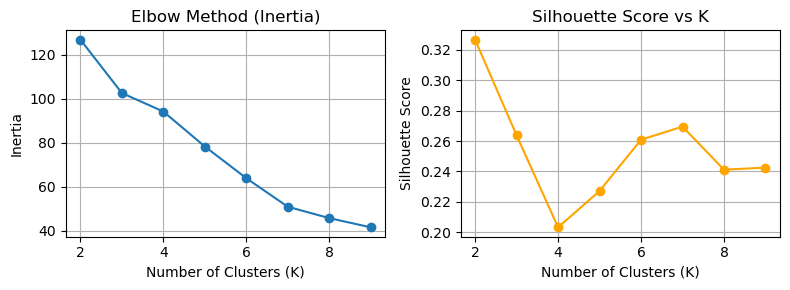

In [11]:
# Range of K values to try
all_functions.baseline(scaled_data,2,10)

In [12]:
kmeans = KMeans(n_clusters=3, random_state=42)
clustering_df['Cluster'] = kmeans.fit_predict(scaled_data)
# map cluster labels to affordability level
cluster_map = {
    0: 'Moderate Affordability',
    1: 'High Affordability',
    2: 'Low Affordability'
}
clustering_df['Affordability'] = clustering_df['Cluster'].map(cluster_map)
clustering_df.head()

,HomeValue_2023,HomeValue_Growth,Income_2023,Income_Growth,Cluster,Affordability
StateName,,,,,,
NY,217244.254634,177.663556,81600.0,20.088300,1,High Affordability
CA,593357.691233,203.980242,89870.0,15.114641,2,Low Affordability
IL,148540.889778,43.330029,87820.0,14.319188,0,Moderate Affordability
TX,216411.865369,87.296005,79060.0,22.783041,1,High Affordability
VA,270847.217093,122.690736,96490.0,22.682772,1,High Affordability


### Results & Interpretation
The clustering grouped states into three affordability tiers. States like Texas, Iowa, and Mississippi were clustered as high affordability, while California, Hawaii were identified as low affordability. Some states formed a moderate affordability group. These clusters are visualized on a U.S. map using color-coded choropleth shading, clearly showing regional patterns in affordability. 

Note: if unable to see here a public link from plotly studio of our visualizationhttps://chart-studio.plotly.com/~eeaguilar02/6/

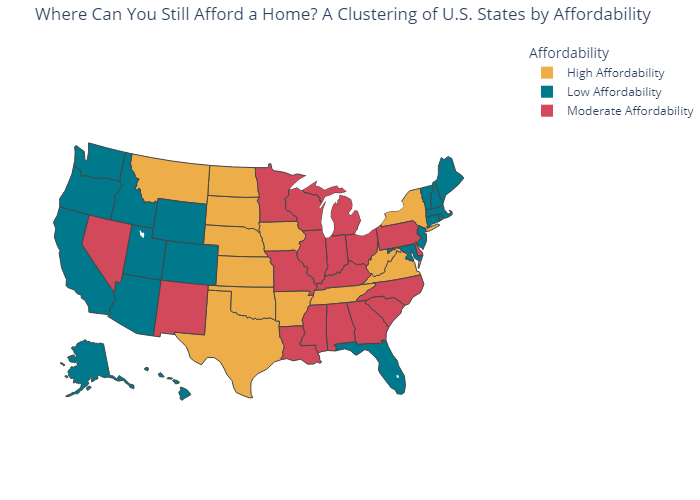

In [13]:
all_functions.showClustersInMap(clustering_df)

## **Where Can You Still Afford a Home? A Clustering of U.S. States by Affordability**
This map shows the results of a K-Means clustering analysis that grouped U.S. states into three categories based on housing affordability: high, moderate, or low affordability based on the relationship between rising home prices and income levels. High Affordable states tend to have relatively low home values and/or healthy income growth, making it easier for residents to afford homes. Many of these are in the central and mountain regions, such as Montana, Texas, and Maine. 
Moderate Affordabile states fall somewhere in the middle — either with moderate home values and income, or a balance of high values with strong income growth. This group includes a mix of Midwestern and Southern states like Tennessee, Michigan, and Pennsylvania.
Low Affordabile states are where home prices have significantly outpaced income growth, making housing much harder to afford. These include coastal states like California, Florida, which are known for high cost-of-living pressures.

The map visually confirms a growing affordability divide in the U.S., with coastal and southern states generally showing lower affordability, while some interior and less densely populated states remain more accessible for homebuyers. The clustering offers a data-driven lens to understand how economic and housing market trends are shaping access to homeownership nationwide.

## **7. Conclusion:**
These Data-driven insights emphasize the growing affordability crisis and regional economic disparities across the U.S.
Understanding these trends is crucial for policymakers, buyers, and anyone concerned about the future of affordable housing in America.

## **8. Future Work:**
Analyze monthly housing trends to determine the best time of year to buy a home based on historical price patterns.
Incorporate additional state-level dataset to refine our understanding of the economic factors driving housing affordability across different regions.

Link to the Jupyter Notebook file: 
Link to the all_functions file: https://github.com/uic-cs418/group-project-stat-squad/blob/main/all_functions.py